# Precipitation Model Testing Using ERA5 Data

This Jupyter Notebook tests a precipitation model using ERA5 reanalysis data as input.

The current version of the model requires the following meteorological inputs at each model time step:

#### Required Inputs

- **Surface Inputs** (from ERA5 Single Levels):
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature

- **Atmospheric Profile Inputs** (from ERA5 Pressure Levels):
  - Temperature at pressure levels
  - Specific humidity at pressure levels

These inputs are used to simulate the evolution of the model state, which is the  **Cloud column liquid water**, including:
- How it evolves over time
- How much is converted to rainwater
- How much reaches the ground as precipitation

To estimate precipitation, all of the above input variables must be provided at each timestep.

#### Data Sources

- **ERA5 Single Levels** (ECMWF): for 2m temperature, dew point, and surface pressure  
- **ERA5 Pressure Levels** (ECMWF): for vertical profiles of temperature and specific humidity

#### Data Preparation

The input datasets are preprocessed and combined externally using the notebook:

```bash
preparing_era_data.ipynb

In [127]:
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from physics_equations import specific_humidity_from_rh,w_sat
import profiles_and_cloud_heights_new as profiles
from constants import g,alpha
import interpolation_lcl as interp
from autoconversion_rate import thresh
import autoconversion_rate as ar
from entrainment_new import calculate_profiles_with_entrainment,lcl_enrtainment_from_ground
import condensation_fluxes
import updraft_emmanuel
import new_rainfall_scheme as nr
import top_outflow as outflow

## Table of Contents

1. [Loading the data](#Loading-the-data)
2. [Running the model](#Running-the-model)
3. [Visualizing the outputs](#Visualizing-the-outputs)


## Loading the data

Interactive cell for initializing the model settings. Choose the desired values, click Apply Settings and then Run All cells again or Run below.

In [128]:
%run widgets.py

The input data used in this model consist of a combined dataset derived from **ERA5 surface values** and **ERA5 atmospheric profiles**.

- **Surface variables** include:
  - 2-meter air temperature
  - Surface pressure
  - 2-meter dew point temperature
  - Specific humidity at the surface

- **Atmospheric profile variables** include:
  - Temperature at multiple pressure levels
  - Pressure levels
  - Specific humidity at those levels

After loading the dataset, only the data corresponding to the **desired time interval** are selected for further analysis.

In [129]:
data_era = xr.open_dataset(r'..\data\model_inputs\ERA5\ERA5combined_profile_data.nc')
data_era = data_era.sel(valid_time=slice(*slice_tuple))

if interp_interval != 'No':
    time_dim = 'valid_time'
    data_era_min = data_era.resample({time_dim: interp_interval}).interpolate('linear')
    data_era = data_era_min.sel(valid_time=slice(*slice_tuple))

Storing the time values and the timestep.

In [131]:
time = data_era.sel(valid_time=slice(*slice_tuple)).valid_time
dt_seconds = np.diff(time).astype('timedelta64[s]').astype(float)

#### Environmental profiles and inputs

The model inputs

In [132]:
T_air = data_era.temperature.values
p_air = data_era.pressure.values
Z = data_era.height.values
T_d = data_era.dew_point_temperature.values
q_v_air = data_era.specific_humidity.values      

#### Parsivel rainfall data

Reading and storing the Parsivel 1 rainfall measurements from Cabauw, which are to be used for the assessment of the model's performance.

In [133]:
parsivel_1 = xr.open_dataset(r'..\data\Cabaw_parsivel\PAR001_Cabauw_202407.nc')
reference_date = np.datetime64("1970-01-01")

# Convert minutes into datetime
datetime_values = reference_date + parsivel_1.epoch_time.astype("timedelta64[s]")
parsivel_1['time'] = datetime_values


rain_rate = parsivel_1.rainfall_rate_32bit.sel(time=slice(*slice_tuple))
hourly_avg = rain_rate.resample(time='5min').mean()

In [134]:
parsivel_1

<xarray.Dataset> Size: 386MB
Dimensions:                      (time: 44641, diameter_classes: 32,
                                  velocity_classes: 32)
Coordinates:
  * time                         (time) datetime64[s] 357kB 2024-07-01 ... 20...
Dimensions without coordinates: diameter_classes, velocity_classes
Data variables: (12/24)
    epoch_time                   (time) int32 179kB ...
    time_as_string               (time) <U19 3MB ...
    lower_diameter_class_limits  (diameter_classes) float32 128B ...
    upper_diameter_class_limits  (diameter_classes) float32 128B ...
    lower_velocity_class_limits  (velocity_classes) float32 128B ...
    upper_velocity_class_limits  (velocity_classes) float32 128B ...
    ...                           ...
    sensor_temperature           (time) float64 357kB ...
    error_code                   (time) float64 357kB ...
    kinetic_energy               (time) float32 179kB ...
    fieldN                       (time, diameter_classes) float32 6MB ...
    fieldV                       (time, diameter_classes) float32 6MB ...
    raw_data                     (time, diameter_classes, velocity_classes) float64 366MB ...
Attributes:
    title:             OTT Parsivel2 disdrometer data
    institution:       Delft University of Technology
    source:            surface observation
    history:           produced on 2024-09-23 by Marc Schleiss
    sensor_type:       OTT Hydromet Parsivel2 optical disdrometer
    site_name:         Cabauw
    sensor_name:       PAR001_Cabauw
    logging_software:  https://github.com/ruisdael-observatory/disdroDL
    project_name:      https://ruisdael-observatory.nl/
    contributors:      Marc Schleiss, Andre Castro, Rob Mackenzie, Mahaut Sou...
    data_license:      CC BY 4.0 https://creativecommons.org/licenses/by-sa/4.0/

## Running the model

### Parcel Profiles

Store the sizes for creating empty arrays

In [135]:
rows = T_air.shape[0]
cols = T_air.shape[1]

#### Initializing Model Output Arrays

Empty arrays are created to store the outputs of the model. These arrays are initialized with dimensions either `(time, height)` or `(time)`, depending on the variable.

**Main Model Outputs**
- **`temp_parcel`**: The parcel temperature profile, computed by solving the model’s thermodynamic equations.
- **`T_v_moist`**: The virtual temperature profile of the parcel.
- **`q_v_parcel`**: The specific humidity profile of the parcel.

**LCL Parameters** 
- **`p_s`**: LCL pressure.
- **`T_s`**: LCL temperature.
- **`lcl_index`**: Index of the lifting condensation level (LCL) in the vertical profile.

**Expanded Environmental Profiles**
All other arrays are expanded to `(time, height + 1)` to later include the LCL values explicitly in the profiles. This ensures that the exact values of the meteorological variables at the LCL level are stored and used in calculations.


In [136]:
temp_parcel = np.zeros((T_air.shape))
p_s = np.zeros(rows)    #cloud base pressure (time)
T_s = np.zeros(rows)    #cloud base temperature (time)
lcl_index = np.zeros(rows) #lcl index (time)

## empty arrays for storing the interpolated profiles (time, height+1)
temp_parcel_new = np.zeros((rows,cols+1))  # new parcel temperature (time, height+1)
air_temp_new = np.zeros((rows,cols+1))   # new temperature profile (time, height+1)
p_new = np.zeros((rows,cols+1))         # new pressure profile (time, height+1)
q_v_new = np.zeros((rows,cols+1))       # new specific humidity profile (time, height+1)
Z_new = np.zeros((rows,cols+1))         # new height profile (time, height+1)

## empty arrays for storing the outputs
T_v_moist = np.zeros((rows,cols+1))
q_v_parcel = np.zeros((rows,cols+1))
Z_b = np.zeros(rows)


#### Implementing the Model: Temperature and Humidity Profiles

This section implements the model functions used to calculate the **parcel's temperature and humidity profiles**. For the temperature profile calculation, the user can select among several conserved quantity approaches:

- `'theta_e'` — Pseudoadiabatic equivalent potential temperature  
- `'theta_l'` — Reversible liquid water potential temperature  
- `'theta_e_reversible'` — Reversible equivalent potential temperature  
- `'GB84'` — Pseudoadiabatic equivalent potential temperature (as defined in Georgakakos and Bras, 1984a)

**Calculation Workflow**

1. *Parcel Temperature and LCL Variables*  
   Using the `profiles_and_cloud_heights.py` module, the parcel temperature profile is computed along with key LCL (Lifting Condensation Level) variables.

2. *Interpolation at the LCL* 
   The `interpolation_lcl.py` module is then used to interpolate both the parcel and environmental profiles so that all relevant meteorological variables are available at the exact height of the LCL.

3. *Parcel Humidity and Virtual Temperature* 
   Finally, with the updated profiles, `profiles_and_cloud_heights.py` is used again to calculate the parcel's specific humidity and virtual temperature profiles.



In [137]:
#import profiles_and_cloud_heights as profiles
#import interpolation_lcl as interp

for i in range(0,T_air.shape[0]):

    #calculating the profiles
    q_t = w_sat(T_d[i],p_air[i,0])
    temp_parcel[i,:],lcl_index[i],p_s[i],T_s[i] = profiles.calculate_parcel_Temp_profile(T_air[i,0],p_air[i,0],T_d[i],p_air[i],theta_type=theta_type)

    #interpolation at the lcl level
    temp_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])

    #calculating the virtual temperature profile of the parcel
    T_v_moist[i,:],q_v_parcel[i,:] = profiles.calculate_parcel_T_v_profile(T_d[i],p_new[i],temp_parcel_new[i,:],int(lcl_index[i]),theta_type=theta_type)

In [138]:
negs = (q_v_parcel < 0).sum()
print(f"Number of negative values in q_l_new: {negs}")

Number of negative values in q_l_new: 0


#### Calculate the environmental virtual temperature profiles

In [139]:
T_v_env = air_temp_new*(1+0.61*q_v_new)

In [140]:
index_ql = 20
grad_qv = np.gradient(w_sat(T_d[20],p_new[20,0]) - q_v_parcel[20,int(lcl_index[20]):], Z_new[20,int(lcl_index[20]):]/1000)*1000
print(grad_qv)

[2.05103324 2.0517976  2.03649309 2.00187438 1.9642571  1.92404897
 1.88061593 1.83410783 1.7846834  1.7375166  1.682908   1.58311357
 1.38859666 1.17242692 0.93564098 0.68833316 0.45342256 0.25875422
 0.12295998 0.04175193 0.02005029 0.01261467]


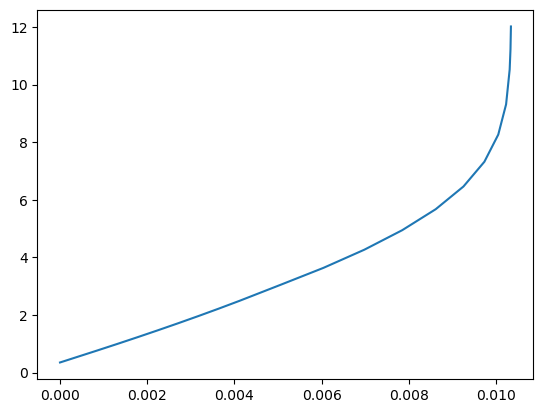

In [141]:
plt.plot(w_sat(T_d[20],p_new[20,0]) - q_v_parcel[index_ql,int(lcl_index[index_ql]):],Z_new[index_ql,int(lcl_index[index_ql]):]/1000)
plt.show()

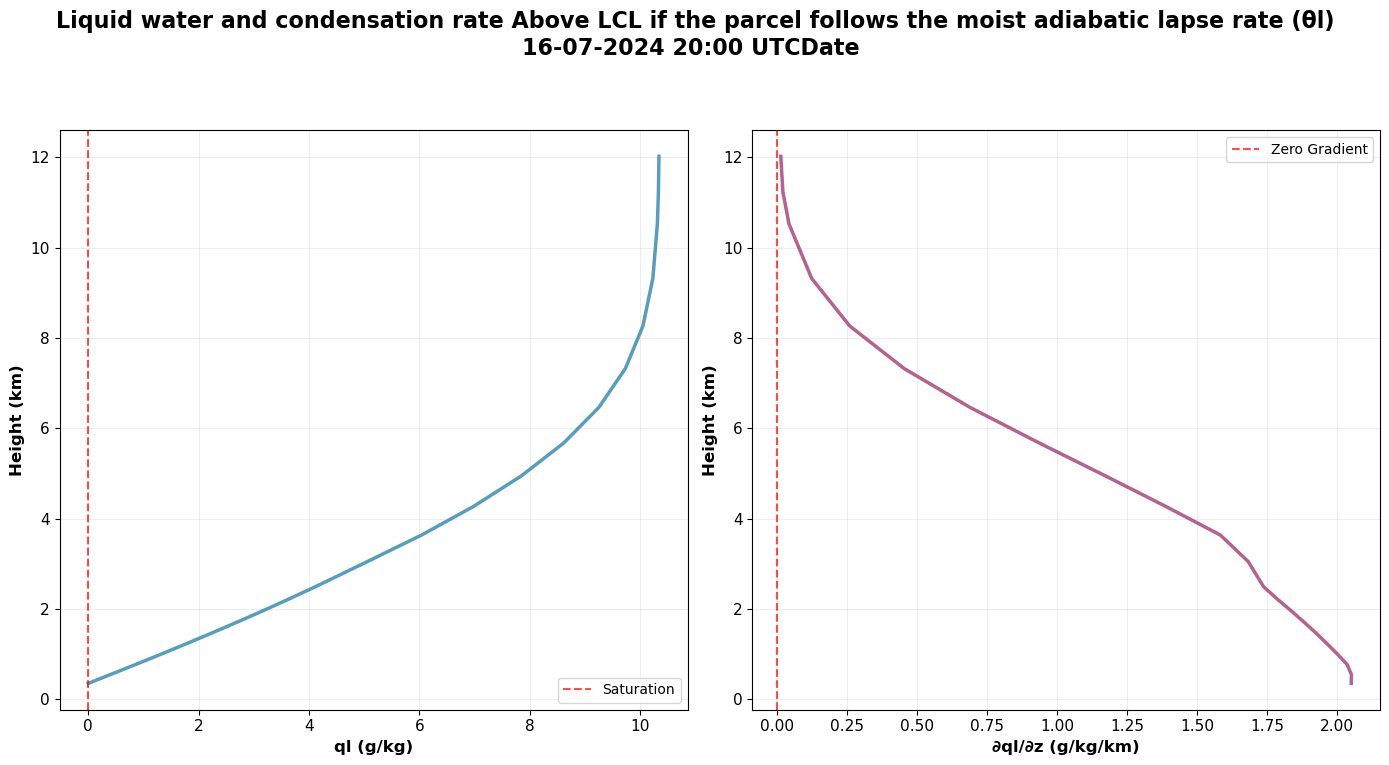

In [142]:
import pandas as pd
# Create a professional subplot for atmospheric profile analysis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
time_dt = pd.to_datetime(time.values)
# Left plot: Saturation deficit vs Height
ax1.plot((w_sat(T_d[20], p_new[20, 0]) - q_v_parcel[index_ql, int(lcl_index[index_ql]):])*1000,
         Z_new[index_ql, int(lcl_index[index_ql]):] / 1000,
         linewidth=2.5, color='#2E86AB', alpha=0.8)

ax1.set_xlabel('ql (g/kg)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Height (km)', fontsize=12, fontweight='bold')
#ax1.set_title('Saturation Deficit Profile\nAbove LCL', fontsize=14, fontweight='bold', pad=15)
ax1.grid(True, alpha=0.3, linewidth=0.5)
ax1.tick_params(axis='both', which='major', labelsize=11)

# Add zero line for reference
ax1.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Saturation')
ax1.legend(fontsize=10)

# Right plot: Water vapor gradient vs Height  
ax2.plot(grad_qv, 
         Z_new[index_ql, int(lcl_index[index_ql]):] / 1000,
         linewidth=2.5, color='#A23B72', alpha=0.8)

ax2.set_xlabel('∂ql/∂z (g/kg/km)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Height (km)', fontsize=12, fontweight='bold') 
#ax2.set_title('Water Vapor Gradient\nAbove LCL', fontsize=14, fontweight='bold', pad=15)
ax2.grid(True, alpha=0.3, linewidth=0.5)
ax2.tick_params(axis='both', which='major', labelsize=11)

# Add zero line for reference
ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=1.5, label='Zero Gradient')
ax2.legend(fontsize=10)

# Improve overall appearance
timestamp_str = time_dt[index_ql].strftime('%d-%m-%Y %H:%M UTC')
fig.suptitle(f'Liquid water and condensation rate Above LCL if the parcel follows the moist adiabatic lapse rate (θl)\n{timestamp_str}' \
'Date ', 
             fontsize=16, fontweight='bold', y=0.95)

# Adjust spacing
plt.tight_layout()
plt.subplots_adjust(top=0.8)

# Optional: Match y-axis ranges for better comparison
y_min = min(ax1.get_ylim()[0], ax2.get_ylim()[0])
y_max = max(ax1.get_ylim()[1], ax2.get_ylim()[1])
ax1.set_ylim(y_min, y_max)
ax2.set_ylim(y_min, y_max)

plt.show()

In [143]:
dZ = np.diff(Z_new[index_ql,int(lcl_index[index_ql]):])/1000
print(w_sat(T_d[20],p_air[20,0]) - q_v_parcel[index_ql,int(lcl_index[index_ql]):],dZ)

[0.         0.00039259 0.00085298 0.00131586 0.00178086 0.00224755
 0.00271541 0.00318382 0.00365205 0.00411921 0.00505676 0.00604124
 0.00698041 0.0078493  0.00861766 0.00925383 0.00973352 0.01005211
 0.01023163 0.0103138  0.01033245 0.01034243] [0.19141011 0.22428809 0.22915454 0.23444794 0.23998413 0.24586414
 0.25213928 0.25870764 0.26561108 0.5537583  0.5887627  0.63129321
 0.67764062 0.72876367 0.78802588 0.85854395 0.94337744 1.05112207
 1.21048438 0.70047852 0.79145996]


### Cloud Heights

#### Determining the Location of the LFC

This step calculates the **Level of Free Convection (LFC)**, indicated by the `lfc_index`. The goal is to determine whether the parcel can reach the LFC based on its thermodynamic state.

- If the conditions allow the parcel to become positively buoyant and reach the LFC, the first entry of the `LFC_index` variable is marked as `"yes"` and a value of `1` is stored.
- If the parcel cannot reach the LFC, the entry is marked as `"no"` and a value of `0` is stored.

This check ensures the model accurately tracks whether convection is initiated in each timestep.


In [144]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [145]:
#empty arrays for storing the outputs
Z_c = np.zeros(rows)
Z_t = np.zeros(rows)
p_t = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c[i],Z_t[i],p_t[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist[i],T_v_env[i],temp_parcel_new[i])

### Entrainment calculations

Cell that automatically selects the correct index of cloud height to implement entrainment from, based on the user selection

In [146]:
if entrainment_beginning=='from LCL':
    start_index = lcl_index + 1
elif entrainment_beginning=='from ground':
    start_index = np.ones(lcl_index.shape[0])

Updating the parcel profiles of temperature and humidity, this time taking entrainment into account 

In [147]:
#from profiles_and_cloud_heights import profiles_with_entrainment
T_parcel_new = np.zeros((rows,cols+1)) 
q_t_parcel_new = np.zeros((rows,cols+1))
Theta_air_arr = np.zeros((rows,cols+1))
q_l_new = np.zeros((rows,cols+1))
q_v_parcel_new = np.zeros((rows,cols+1))
for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i])     #Siebesma et al. (2003)
    T_parcel_new[i],q_t_parcel_new[i],q_l_new[i],q_v_parcel_new[i],Theta_air_arr[i] = calculate_profiles_with_entrainment(T_s[i], T_d[i], air_temp_new[i], temp_parcel_new[i], p_s[i], p_new[i], q_v_new[i], Z_new[i,], int(start_index[i]), entrainment_rate, theta_type)


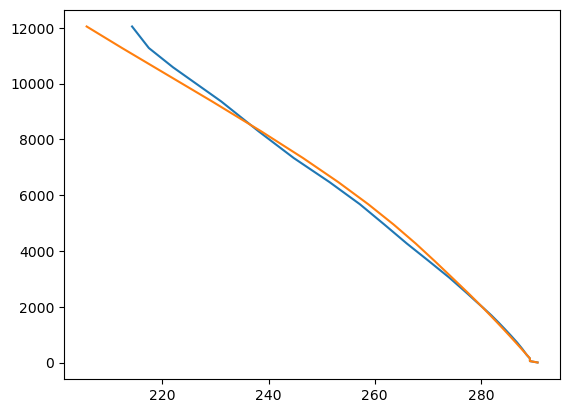

In [148]:
plt.plot(T_parcel_new[0],Z_new[0])
plt.plot(temp_parcel_new[0],Z_new[0])
plt.show()

In [149]:
#q_l_new = np.zeros((rows,cols+1))
#q_v_parcel_new = 1*q_v_parcel

for i in range(0,rows):
    #print(i)
    entrainment_rate = min(0.001,1/Z_c[i]) 
    #q_l_new[i],q_v_parcel_new[i] = profiles.calculate_humidity_profiles_with_entrainment(q_t_parcel_new[i],p_new[i],T_parcel_new[i],T_d[i],int(start_index[i]))
    
    # if entrainment starts from the ground, then the LCL changes so it has to be recalculated and interpolated
    if entrainment_beginning=='from ground':
        
        temp_parcel[i] = np.delete(T_parcel_new[i],int(lcl_index[i]))
        p_air[i] = np.delete(p_new[i],int(lcl_index[i]))
        Z[i] = np.delete(Z_new[i],int(lcl_index[i]))
        T_air[i] = np.delete(air_temp_new[i],int(lcl_index[i]))
        q_v_air[i] = np.delete(q_v_new[i],int(lcl_index[i]))

        lcl_index[i],T_s[i],p_s[i] = lcl_enrtainment_from_ground(T_parcel_new[i],p_new[i],T_d[i],Z_new[i])
        lcl_index[i] = np.clip(int(lcl_index[i]), 0, len(p_air[i]) - 3)     #for cases where the LCL is in very high altitude

        #interpolation at the lcl level
        T_parcel_new[i], p_new[i], Z_new[i], lcl_index[i], air_temp_new[i], q_v_new[i] = interp.insert_lcl_values(temp_parcel[i],p_air[i],Z[i],int(lcl_index[i]),T_s[i],p_s[i],T_air[i,:],q_v_air[i,:])
    



Calculating the new parcel virtual temperature profile after considering entrainment 

In [150]:
if theta_type=='theta_e' or theta_type=='GB84':
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new)
else:
    T_v_moist_new = T_parcel_new*(1+0.61*q_v_parcel_new- q_l_new)

#### LFC height

Calculating the location of the LFC, which is given by the lfc_index, as well as if the conditions allow the parcel to reach it. If so, then the first value of the LFC_index variable will print "yes" and we are storing 1. Otherwise, we get "no" and 0 is stored.

In [151]:
LFC_index = np.zeros((rows,2))  #empty array for storing the LFC index

for i in range(0,rows):
    flag, lfc_idx = profiles.find_lfc_level(
        T_v_moist_new[i], T_v_env[i], Z_new[i], int(lcl_index[i])
    )
    # store the numeric index in column 0
    LFC_index[i, 1] = lfc_idx

    # if you also want a numeric code for “yes” / “no”, e.g. 1/0:
    LFC_index[i, 0] = 1 if flag.lower() == "yes" else 0

#### Determining the cloud top and cloud depth
Finding the **cloud top height** and **pressure** and the **resulting cloud depth**, again by calling `profiles_and_cloud_heights.py`.

In [152]:
#empty arrays for storing the outputs
Z_c_new = np.zeros(rows)
Z_t_new = np.zeros(rows)
p_t_new = np.zeros(rows)

#finding cloud top and cloud depth
for i in range(0,rows):
    Z_c_new[i],Z_t_new[i],p_t_new[i] = profiles.find_cloud_top_and_depth(LFC_index[i],Z_new[i],Z_new[i,int(lcl_index[i])],p_new[i],T_v_moist_new[i],T_v_env[i],T_parcel_new[i])

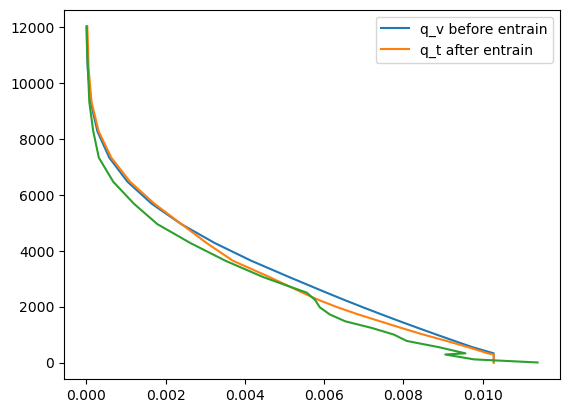

In [153]:
index = 21
plt.plot(q_v_parcel[index],Z_new[index],label='q_v before entrain')
#plt.plot(q_v_parcel[index],Z_new[index])
#plt.plot(q_v_new[index],Z_new[index])
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_t after entrain')
plt.plot(q_v_new[index],Z_new[index])
#plt.plot(q_v_parcel_new[index],Z_new[index])
#plt.plot(q_l_new[index],Z_new[index])
#plt.axhline(y=Z_new[index,int(lcl_index[index+1])],color='blue')
#plt.axhline(y=Z_t[index],color='green')
#plt.axhline(y=Z_t_new[index],color='red')
plt.legend()
plt.show()

In [154]:
def find_top_index(Z_t_new,Z_c_new,Z_new):
    if Z_t_new == 0 or Z_c_new == 1:  
        top_index = 0
    else:
         top_index = np.argmax((Z_t_new - Z_new) <= 0)
    return top_index

### Updraft speed

Using the parcel and environmental virtual temperature profiles, we calculate the parcel **updraft velocity profile** by calling the `updraft_emmanuel.py`. To do so, we have to first find the index of cloud top height. 

In [155]:
#import updraft_emmanuel

w_parcel_max= np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    w_parcel_max[i],CAPE = updraft_emmanuel.calculate_parcel_updraft_velocity(Z_new[i],T_v_moist_new[i],T_v_env[i],LFC_index[i,1],top_index)

In [156]:
w_parcel_max

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  1.26751129,  5.8531366 ,
       12.25663946, 14.43603038,  9.27010301,  0.        ,  6.03564284,
       10.35437162, 11.96493978,  5.0685825 ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ])

In [157]:
n_nans = np.isnan(q_t_parcel_new).sum()
print(f"Number of NaNs in q_l_new: {n_nans}")

Number of NaNs in q_l_new: 0


### State calculation and update

#### Calculating the Temporal Evolution of the Cloud System

This section computes the **state evolution of the cloud system over time**. The evolution focuses on changes in cloud liquid water content due to condensation and precipitation processes.

**Components of the Moisture Budget**

- *Condensation (Inflow)*  
  The amount of condensed water within the cloud is calculated using the `GB84.py` module, based on the approach of Georgakakos and Bras (1984).

- *Outflow (Losses)*  
  Moisture outflow from the cloud includes:
  - *Rainwater formation*: Determined via the `autoconversion_rate.py` module, which estimates the rate at which cloud water is converted to rain.
  - *Droplet removal by updrafts*: Handled by the `top_outflow.py` module, representing the loss of cloud droplets entrained by upward-moving air.

Together, these components allow the model to track the cloud water budget and estimate precipitation over time.


In [158]:
#import autoconversion_rate as ar
#from GB84_eqs import f as flux, rho_m
#import top_outflow as outflow

#empty arrays for storing condensation flux and state values
f_arr = np.zeros(rows)
X =np.zeros(rows)


for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])  

    w_avg = w_parcel_max[i]/2
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    #print(rho,w_avg)
    if w_parcel_max[i] == 0:
        #print(i)
        # no convection == no flux
        f_arr[i] = 0
    else:
        
        f_arr[i] = condensation_fluxes.condensation_flux(rho,w_avg,q_l_new[i],int(lcl_index[i]),top_index,theta_type=theta_type)
        print(f_arr[i])
    if i<rows-1:
        #if X[i]/Z_c_new[i] > 2.5e-3:        #capping the X values so that they don't abnormally high
            #X[i] = 2.5e-3*Z_c_new[i]

    #state update
        X[i+1] = X[i] +f_arr[i]*dt_seconds[i] - ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)*dt_seconds[i]# - outflow.calculate_water_top_outflow(X[i],top_index,Z_b[i],Z_new[i],w_parcel_max[i],int(LFC_index[i,1]),dt_seconds[i])*dt_seconds[i]
        X[i+1] = max(0,X[i+1])

0.0003456162087898999
0.008127099550973923
0.0290657923722798
0.03466837342587974
0.02013750982364847
0.011290214478014787
0.019477626770466296
0.02240433249409365
0.006263514293567767


In [159]:
for i in range(0,rows):
    a = q_l_new[i,int(find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i]))]
    if a>0:
        print(a)

0.0004770911149869807
0.0026408546024389093
0.004662315346004034
0.004827821256226981
0.004159199954139912
0.00351415950477405
0.003612258681888434
0.003651806981006302
0.002297047252006931


In [160]:
for i in range(0,rows):
    if f_arr[i]>0:
        print(f_arr[i])

0.0003456162087898999
0.008127099550973923
0.0290657923722798
0.03466837342587974
0.02013750982364847
0.011290214478014787
0.019477626770466296
0.02240433249409365
0.006263514293567767


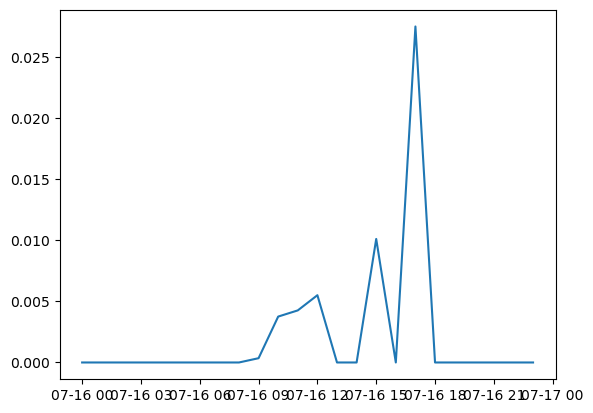

In [161]:
plt.plot(time,X/Z_c)
#plt.ylim(0,10)
plt.show()  


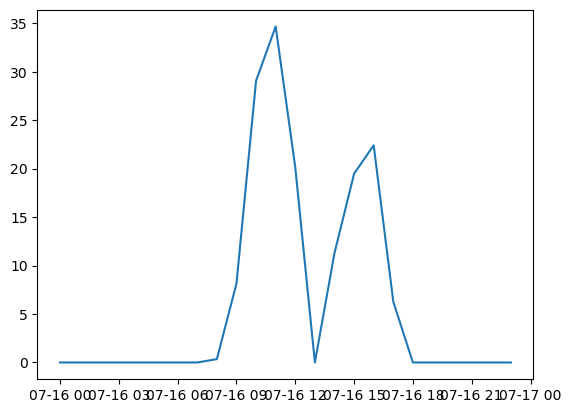

In [162]:
plt.plot(time,f_arr*1000)
plt.show()

In [163]:
print(max(X),np.where(X==max(X)))

80.65559697873714 (array([17], dtype=int64),)


In [164]:
total_water = np.zeros(rows)
for i in range(0,rows):
    top_index = find_top_index(Z_t_new[i],Z_c_new[i],Z_new[i])
    if theta_type == "GB84" or theta_type == "theta_e":         #in pseudoadiabatic approach water is constantly removed, 
        total_water[i] = np.sum(q_l_new[i,int(lcl_index[i]):int(top_index)+1])                                                   #so integrate over all cloud heights
    
    else:                                                       #in reversible approach water is staying inside the parcel,
        total_water[i] = q_l_new[i,int(top_index)]                                                  #so total water is what reaches the cloud top

In [165]:
np.mean(total_water)

0.0012434397788946888

### Rainfall rates

#### Precipitation Rate Calculation at Ground Level

The process to calculate the precipitation rate reaching the ground involves multiple steps:

- **Rainfall Rate from Cloud:**  
   The initial rate of rainfall exiting the cloud is determined by executing the script `autoconversion_rate.py`.

- **Rain Droplet Size Distribution:**  
   Using the calculated rainfall rate, the script `new_rainfall_scheme.py` assumes and computes a raindrop size distribution.

- **Estimation of Surface Precipitation:**  
   Based on the droplet size distribution, the model estimates the fraction of raindrops that survive evaporation during their descent and subsequently reach the ground as precipitation.


In [166]:
#import autoconversion_rate as ar
#import new_rainfall_scheme as nr

# empty arrays for storing the rainfall rates and the size distribution parameters

R = np.zeros(rows)  #rainfall rate at the cloud base
P = np.zeros(rows)  #precipitation rate at the surface

lambda_arr = np.zeros(rows)     #slope parameter of Gamma distribution
mu_result_arr = np.zeros(rows)  #shape parameter of Gamma distribution
Dc_arr = np.zeros(rows)         #critical diameter for evaporation


for i in range(0,rows):
    #print(i)
    rho = condensation_fluxes.rho_m(T_s[i],T_parcel_new[i,top_index],p_s[i],p_t_new[i])
    R[i] = ar.cloud_water_autoconversion_rate(X[i],Z_c_new[i],thresh)
    if R[i]<=2.7e-5:      #excluding precipitation rates below 0.1 mm/h due to numerical issues
        P[i] = 0
    else:
        Lambda_result = nr.solve_lambda_mu_dependent(R[i], alpha, w_parcel_max[i]/2*100)
        mu_result = nr.mu_from_lambda(Lambda_result)
        #print(mu_result,Lambda_result)
        D_critical = ar.critical_diameter(T_parcel_new[i,0], p_new[i,0], T_d[i], Z_new[i,int(lcl_index[i])], Z_c_new[i],w_parcel_max[i]/2*100).calculate_evaporation_critical_diameter()
        P[i] = nr.ground_precipitation_rate(R[i], mu_result, Lambda_result, D_critical*100,w_parcel_max[i]/2*100,alpha)

In [167]:
R

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.00041144,
       0.02778017, 0.03215445, 0.04166342, 0.        , 0.        ,
       0.03955321, 0.        , 0.07997729, 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        ])

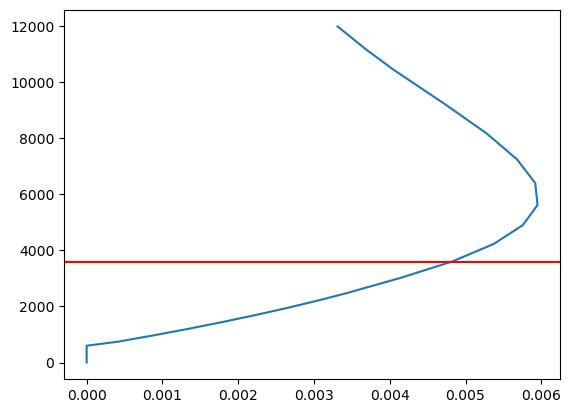

In [168]:
index_max = np.argmax(Z_t_new)
plt.plot(q_l_new[index_max],Z_new[index_max])
#plt.plot(q_v_parcel[index_max],Z_new[index_max])
#plt.plot(q_v_parcel_new[index_max],Z_new[index_max])
plt.axhline(y=Z_t_new[index_max],color='red')
#plt.axhline(y=Z_new[index_max,int(LFC_index[index_max,1])],color='green')
plt.show()

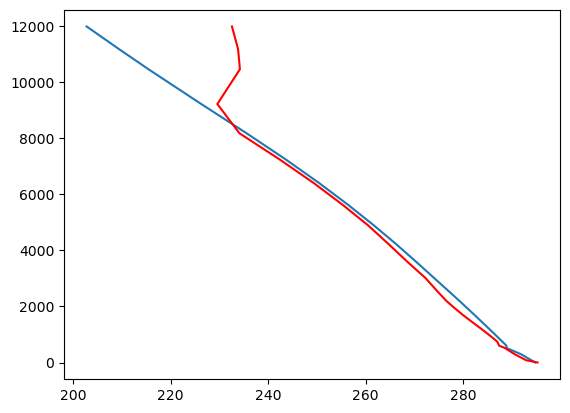

In [169]:
plt.plot(T_v_moist[index_max],Z_new[index_max])
#plt.plot(T_v_moist_new[index_max],Z_new[index_max])
plt.plot(T_v_env[index_max],Z_new[index_max],color='red')
plt.show()

## Visualizing the outputs

#### Rainfall rate

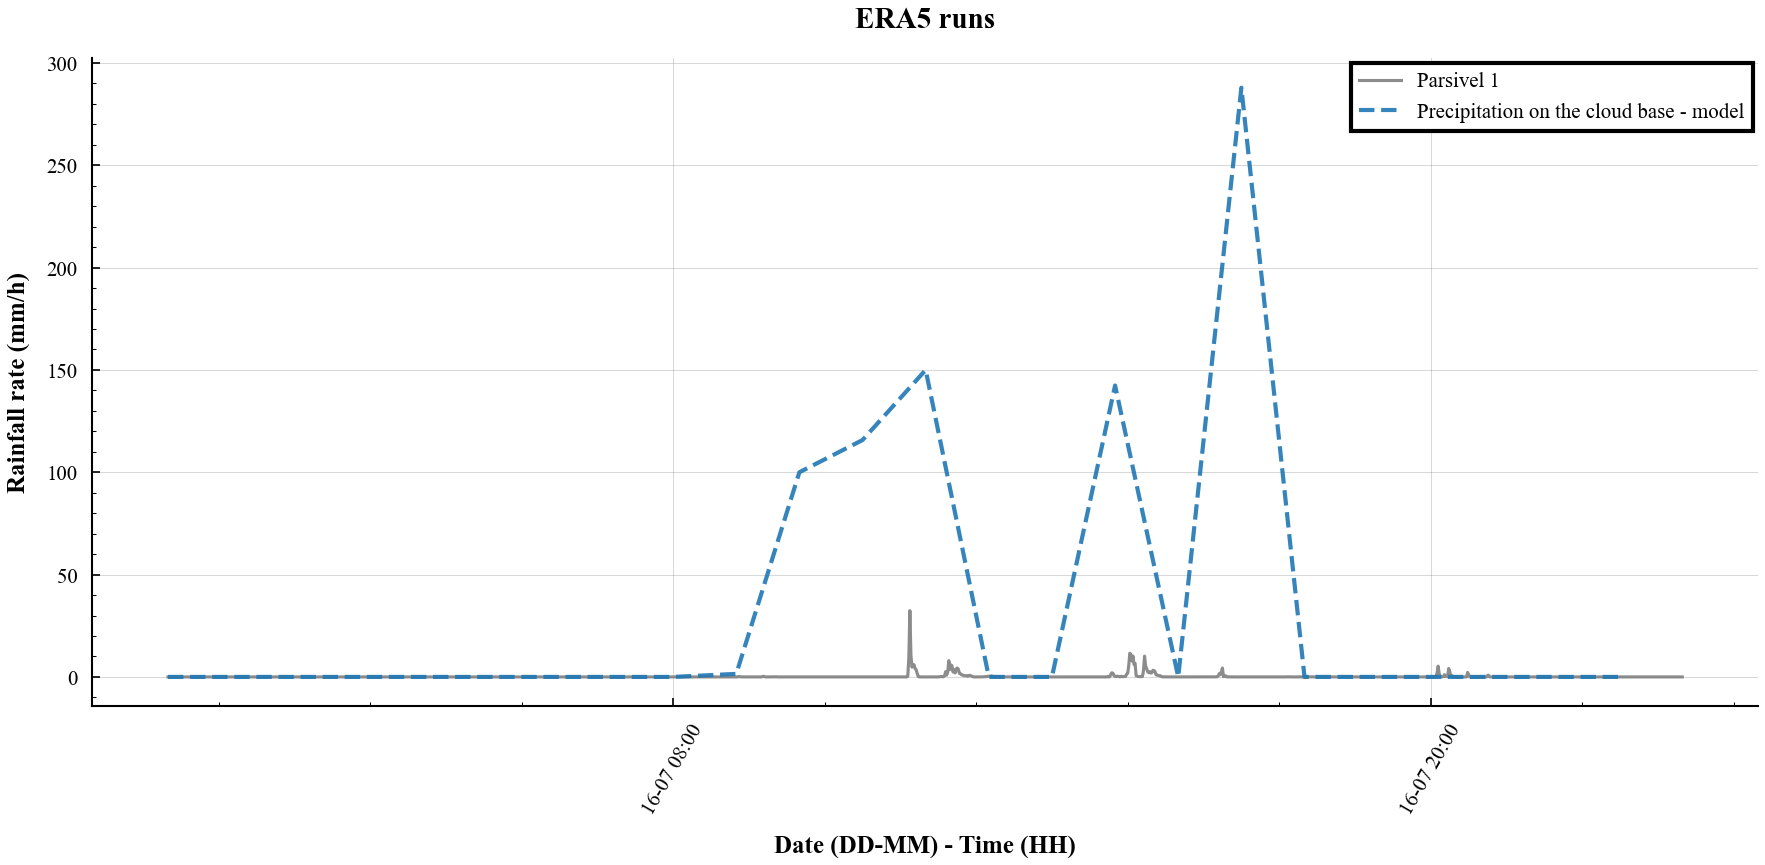

In [170]:
# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'parsivel': '#808080',     # Grey
    'model': '#1f77b4',       # Blue
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
#plt.plot(time,P*3600,label='Precipitation on the ground',color='blue')
line_parsivel = ax.plot(rain_rate.time, rain_rate, 
                       color=colors['parsivel'], 
                       label='Parsivel 1',
                       linewidth=1.5 * SCALE_FACTOR,
                       alpha=0.9)

line_model = ax.plot(time, R * 3600, 
                    color=colors['model'], 
                    linestyle='--', 
                    label='Precipitation on the cloud base - model',
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

#plt.plot(time,R_old*3600,color='red',linestyle='--',label='Precipitation on the ground - model')
#plt.plot(rain_rate.time[indexes_strat],rain_rate[indexes_strat],color='gray',label='Stratiform event')

# Scientific axis labels with units
ax.set_xlabel('Date (DD-MM) - Time (HH)', fontweight='bold')
ax.set_ylabel('Rainfall rate (mm/h)', fontweight='bold')
ax.set_title('ERA5 runs', fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Scientific legend positioning - scaled by SCALE_FACTOR
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)

# Professional tick formatting
# Only apply scalar formatting to y-axis (rainfall rate)
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed for y-axis only
from matplotlib.ticker import ScalarFormatter
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# For time axis, use proper date formatting - scale-aware
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor
if SCALE_FACTOR >= 1.0:
    tick_interval = 6  # Every 6 hours for full size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    tick_interval = 12  # Every 12 hours for medium size
    date_format = '%d-%m %H:%M'  # Changed to d-m format
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    date_format = '%d-%m'  # Changed to d-m format for very small plots
    rotation = 45

ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=rotation, fontsize=10*SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

# Optional: Save with scientific filename convention
# plt.savefig(f'rainfall_rate_era5_entrainment.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')
#             format='pdf', dpi=600, bbox_inches='tight')

In [171]:
import pickle
import pandas as pd
import numpy as np
from datetime import datetime

# Method 1: Save as pickle (preserves exact Python objects including datetime)
def save_datasets_pickle():
    """Save all datasets as pickle files"""
    datasets = {
        'rain_rate': rain_rate,
        'time': time,
        "state":X,
        'R': R,
        'Z_t': Z_t,
        'Z_t_new': Z_t_new,
        'metadata': {
            'theta_type': theta_type,
            'entrainment_beginning': entrainment_beginning,
            'slice_str': slice_str,
            'slice_tuple': slice_tuple,
            'start_dt': start_dt,
            'end_dt': end_dt,
            'save_timestamp': datetime.now().isoformat()
        }
    }
    
    with open('era5_datasets_1hr.pkl', 'wb') as f:
        pickle.dump(datasets, f)
    
    print("✓ Datasets saved as era5_datasets_1hr.pkl")

In [172]:
save_datasets_pickle()

✓ Datasets saved as era5_datasets_1hr.pkl


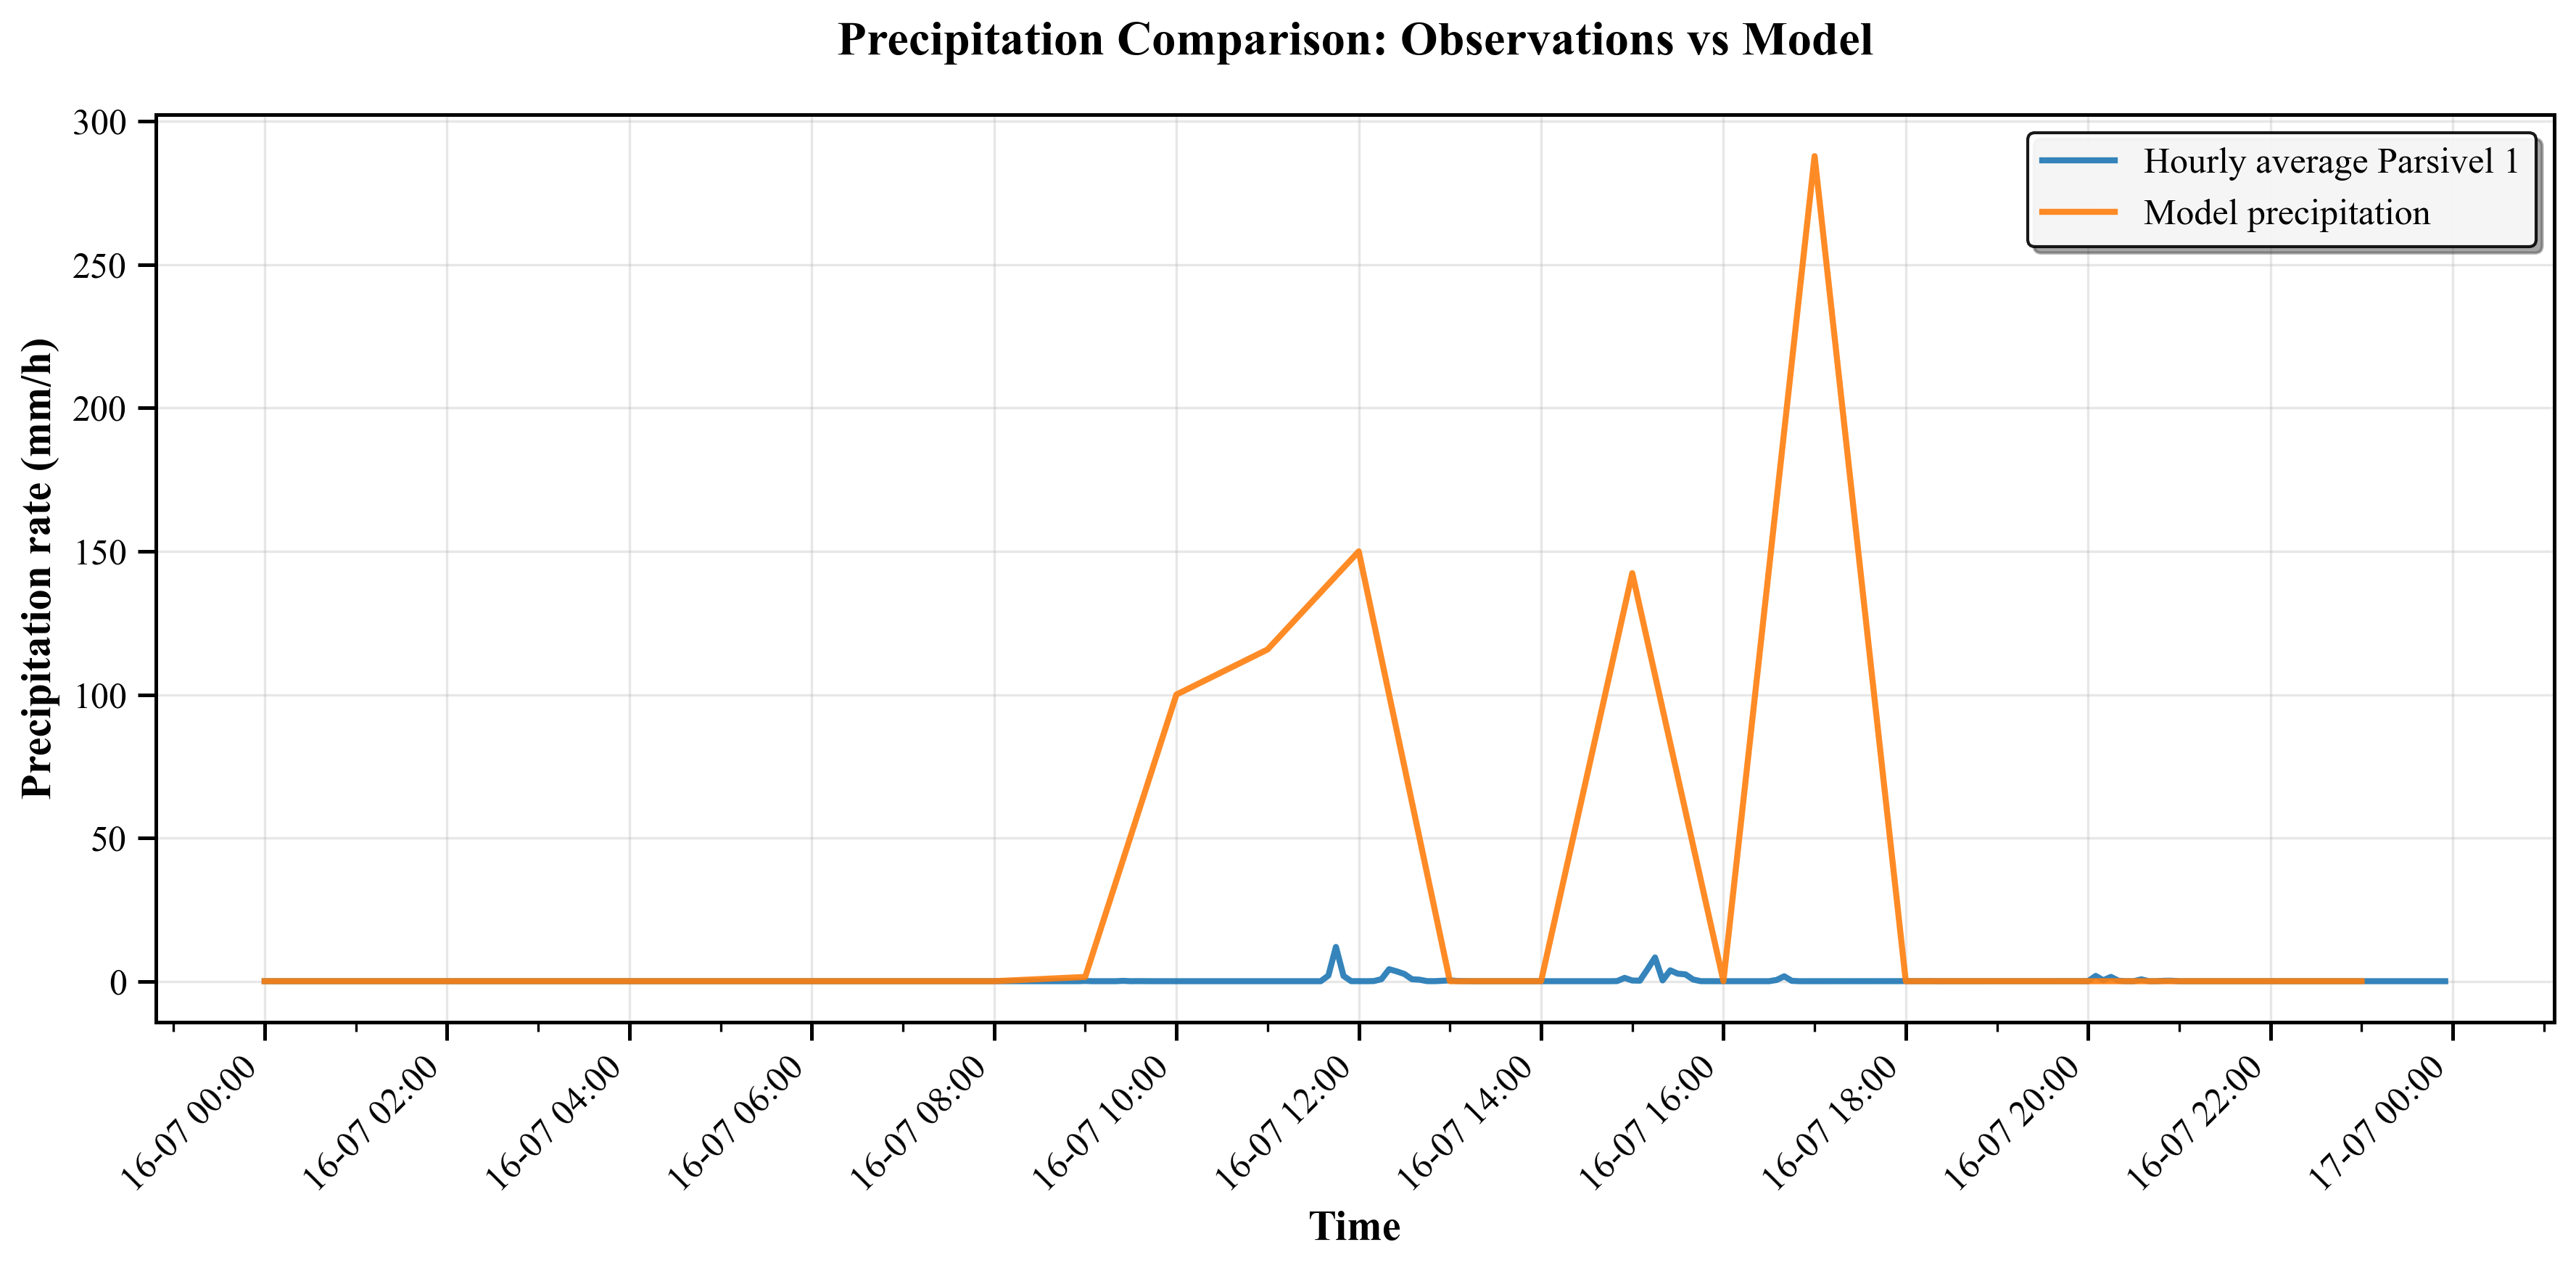

In [173]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 1.0  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'hourly_avg': '#1f77b4',     # Blue
    'model': '#ff7f0e',          # Orange
}

# Plot with scaled line widths
ax.plot(hourly_avg.time, hourly_avg,
        color=colors['hourly_avg'], 
        label='Hourly average Parsivel 1',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

ax.plot(time_dt, R * 3600,
        color=colors['model'], 
        label='Model precipitation',
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Precipitation rate (mm/h)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Precipitation Comparison: Observations vs Model',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper right',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

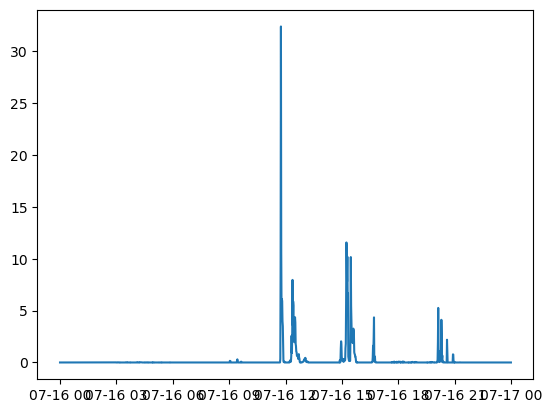

In [174]:
plt.plot(rain_rate.time, rain_rate)
plt.show()

#### Virtual Temperature profiles at different times

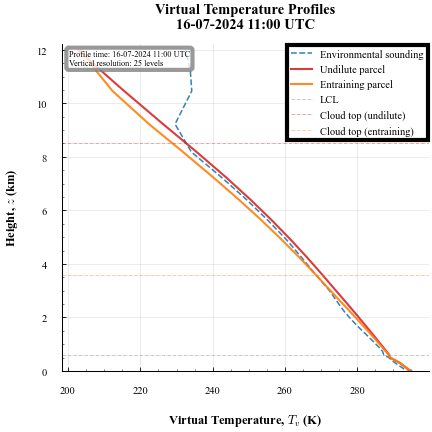

In [175]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.25  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with scientific aspect ratio - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(6 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient = ax.plot(T_v_env[index_2], Z_new[index_2]/1000,  # Convert to km
                      color=colors['ambient'], 
                      label='Environmental sounding',
                      linestyle='--', 
                      linewidth=1.5 * SCALE_FACTOR,
                      alpha=0.9)

line_dry = ax.plot(T_v_moist[index_2], Z_new[index_2]/1000,
                  color=colors['no_entrainment'], 
                  label='Undilute parcel',
                  linestyle='-', 
                  linewidth=2.0 * SCALE_FACTOR,
                  alpha=0.9)

line_entrain = ax.plot(T_v_moist_new[index_2], Z_new[index_2]/1000,
                      color=colors['with_entrainment'], 
                      label='Entraining parcel',
                      linestyle='-', 
                      linewidth=2.0 * SCALE_FACTOR,
                      alpha=0.9)

# Scientific axis labels with units
ax.set_xlabel('Virtual Temperature, $T_v$ (K)', fontweight='bold')
ax.set_ylabel('Height, $z$ (km)', fontweight='bold')

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')
ax.set_title(f'Virtual Temperature Profiles\n{timestamp_str}',
             fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax.set_axisbelow(True)

# Minor ticks for precision
ax.minorticks_on()

# Add horizontal reference lines with labels - scaled line widths by SCALE_FACTOR
lcl_line = ax.axhline(y=Z_new[index_2,int(lcl_index[index_2])]/1000, 
                     color='grey', linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                     label='LCL')

zt_line = ax.axhline(y=Z_t[index_2]/1000, 
                    color=colors['no_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                    label='Cloud top (undilute)')

zt_new_line = ax.axhline(y=Z_t_new[index_2]/1000, 
                        color=colors['with_entrainment'], linestyle='-.', linewidth=0.5 * SCALE_FACTOR, alpha=0.8,
                        label='Cloud top (entraining)')

# Set axis limits with some padding for scientific presentation
temp_range = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
              np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding = (temp_range[1] - temp_range[0]) * 0.05
ax.set_xlim(temp_range[0] - temp_padding, temp_range[1] + temp_padding)

height_max = Z_new[index_2].max()/1000
ax.set_ylim(0, height_max * 1.02)

# Scientific legend positioning - now includes horizontal lines
legend = ax.legend(loc='upper right',
                  frameon=True,
                  framealpha=1.0,
                  edgecolor='black',
                  facecolor='white',
                  borderaxespad=0.5 * SCALE_FACTOR,
                  ncol=1)  # Single column for cleaner look

# Add subtle background for better contrast
#ax.set_facecolor('#fafafa')

# Professional tick formatting
ax.ticklabel_format(style='plain', axis='x')
ax.ticklabel_format(style='plain', axis='y')

# Ensure scientific notation if needed
from matplotlib.ticker import ScalarFormatter
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

plt.tight_layout()

# Optional: Add metadata text box for scientific context - scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8 * SCALE_FACTOR,
        verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

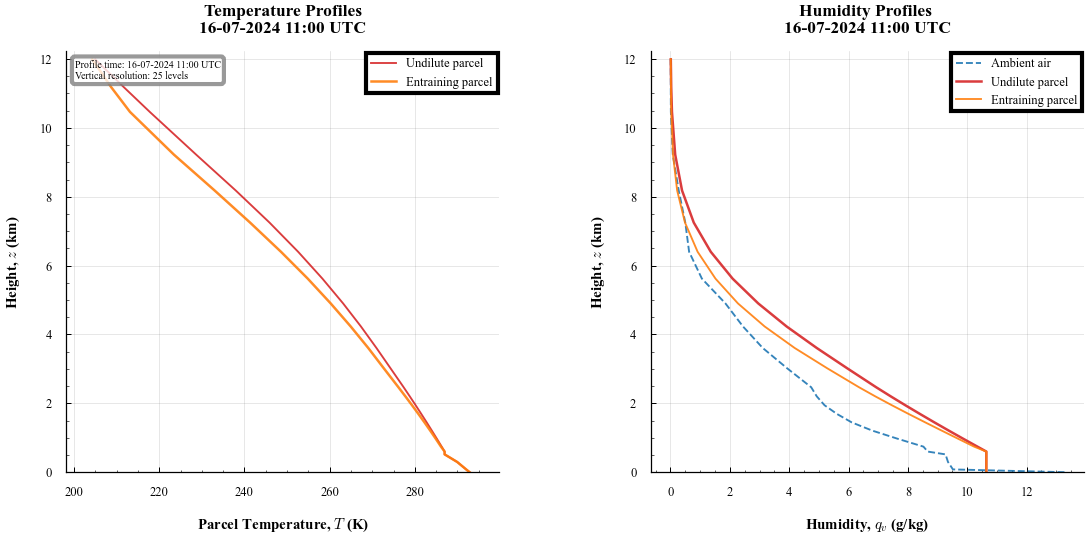

In [176]:
index_2 = 11
import pandas as pd
import numpy as np

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings for scientific publications - scaled by SCALE_FACTOR
    'font.size': 11 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Computer Modern Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern for math
    'text.usetex': False,  # Set to True if LaTeX is available
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.0 * SCALE_FACTOR,
    'axes.labelsize': 12 * SCALE_FACTOR,
    'axes.titlesize': 14 * SCALE_FACTOR,
    'axes.labelweight': 'normal',
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': 'black',
    'axes.labelcolor': 'black',
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 10 * SCALE_FACTOR,
    'ytick.labelsize': 10 * SCALE_FACTOR,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4 * SCALE_FACTOR,
    'xtick.minor.size': 2 * SCALE_FACTOR,
    'ytick.major.size': 4 * SCALE_FACTOR,
    'ytick.minor.size': 2 * SCALE_FACTOR,
    'xtick.major.width': 0.8 * SCALE_FACTOR,
    'xtick.minor.width': 0.5 * SCALE_FACTOR,
    'ytick.major.width': 0.8 * SCALE_FACTOR,
    'ytick.minor.width': 0.5 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 10 * SCALE_FACTOR,
    'legend.framealpha': 1.0,
    'legend.edgecolor': 'black',
    'legend.fancybox': False,
    
    # Figure quality - keep DPI high for quality
    'figure.dpi': 300,
    'savefig.dpi': 600,  # Higher DPI for publication
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05 * SCALE_FACTOR,
    'savefig.format': 'pdf',  # Vector format preferred
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure with two subplots side by side - scaled by SCALE_FACTOR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Scientific color palette (colorblind-friendly)
colors = {
    'ambient': '#1f77b4',      # Blue
    'no_entrainment': '#d62728',  # Red  
    'with_entrainment': '#ff7f0e'  # Orange
}

# Format timestamp for title
timestamp_str = time_dt[index_2].strftime('%d-%m-%Y %H:%M UTC')

# ===== LEFT SUBPLOT (ax1) =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient1 = ax1.plot(temp_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['no_entrainment'], 
                        label='Undilute parcel', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry1 = ax1.plot(T_parcel_new[index_2], Z_new[index_2]/1000,
                    color=colors['with_entrainment'], 
                    label='Entraining parcel',
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

# Scientific axis labels with units
ax1.set_xlabel('Parcel Temperature, $T$ (K)', fontweight='bold')
ax1.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax1.set_title(f'Temperature Profiles\n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax1.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax1.set_axisbelow(True)

# Minor ticks for precision
ax1.minorticks_on()

# Set axis limits with some padding for scientific presentation
temp_range1 = [np.min([T_v_env[index_2].min(), T_v_moist[index_2].min(), T_v_moist_new[index_2].min()]),
               np.max([T_v_env[index_2].max(), T_v_moist[index_2].max(), T_v_moist_new[index_2].max()])]
temp_padding1 = (temp_range1[1] - temp_range1[0]) * 0.05
ax1.set_xlim(temp_range1[0] - temp_padding1, temp_range1[1] + temp_padding1)

height_max1 = Z_new[index_2].max()/1000
ax1.set_ylim(0, height_max1 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend1 = ax1.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# ===== RIGHT SUBPLOT (ax2) - Duplicate =====
# Plot with scientific line styles and markers - scaled line widths by SCALE_FACTOR
line_ambient2 = ax2.plot(1000*q_v_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['ambient'], 
                        label='Ambient air',
                        linestyle='--', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

line_dry2 = ax2.plot(1000*q_v_parcel[index_2], Z_new[index_2]/1000,
                    color=colors['no_entrainment'], 
                    label='Undilute parcel',
                    linestyle='-', 
                    linewidth=2.0 * SCALE_FACTOR,
                    alpha=0.9)

line_moist = ax2.plot(1000*q_v_parcel_new[index_2], Z_new[index_2]/1000,  # Convert to km
                        color=colors['with_entrainment'], 
                        label='Entraining parcel',
                        linestyle='-', 
                        linewidth=1.5 * SCALE_FACTOR,
                        alpha=0.9)

# Scientific axis labels with units
ax2.set_xlabel('Humidity, $q_v$ (g/kg)', fontweight='bold')
ax2.set_ylabel('Height, $z$ (km)', fontweight='bold')
ax2.set_title(f'Humidity Profiles \n{timestamp_str}',
              fontweight='bold', pad=15 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax2.grid(True, alpha=0.3, linewidth=0.5 * SCALE_FACTOR, color='gray')
ax2.set_axisbelow(True)

# Minor ticks for precision
ax2.minorticks_on()

# Add horizontal reference lines with labels

height_max2 = Z_new[index_2].max()/1000
ax2.set_ylim(0, height_max2 * 1.02)

# Scientific legend positioning - scaled by SCALE_FACTOR
legend2 = ax2.legend(loc='upper right',
                    frameon=True,
                    framealpha=1.0,
                    edgecolor='black',
                    facecolor='white',
                    borderaxespad=0.5 * SCALE_FACTOR,
                    ncol=1)

# Professional tick formatting for both subplots
for ax in [ax1, ax2]:
    ax.ticklabel_format(style='plain', axis='x')
    ax.ticklabel_format(style='plain', axis='y')
    
    # Ensure scientific notation if needed
    from matplotlib.ticker import ScalarFormatter
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))

# Adjust spacing manually instead of tight_layout to preserve subplot spacing
plt.subplots_adjust(left=0.08, right=0.95, top=0.9, bottom=0.12, wspace=0.35)

# Optional: Add metadata text box for scientific context - only on left subplot, scaled font size
textstr = f'Profile time: {timestamp_str}\nVertical resolution: {len(Z_new[index_2])} levels'
props = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray')
ax1.text(0.02, 0.98, textstr, transform=ax1.transAxes, fontsize=8 * SCALE_FACTOR,
         verticalalignment='top', bbox=props)

# Show the plot
plt.show()
# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)
# Optional: Save with scientific filename convention
# plt.savefig(f'virtual_temperature_profiles_{timestamp_str.replace(" ", "_").replace(":", "")}.pdf', 
#             format='pdf', dpi=600, bbox_inches='tight')

#### Cloud top and base

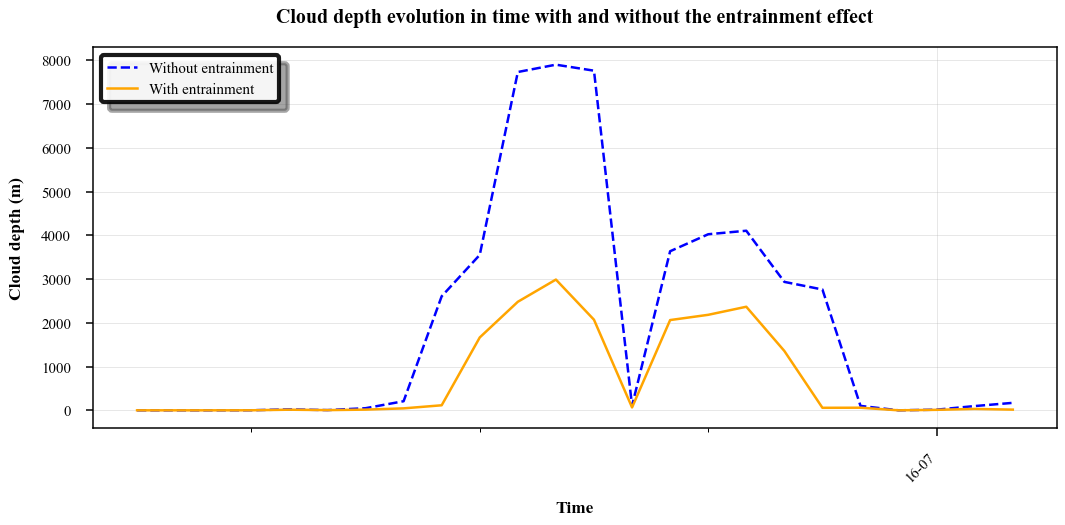

In [177]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.3  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, np.maximum(0, Z_t - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='blue', 
        label='Without entrainment',
        linestyle='--',
        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, np.maximum(0, Z_t_new - Z_new[np.arange(Z_new.shape[0]), lcl_index.astype(int)]),
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud depth (m)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud depth evolution in time with and without the entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

#### Updraft velocity

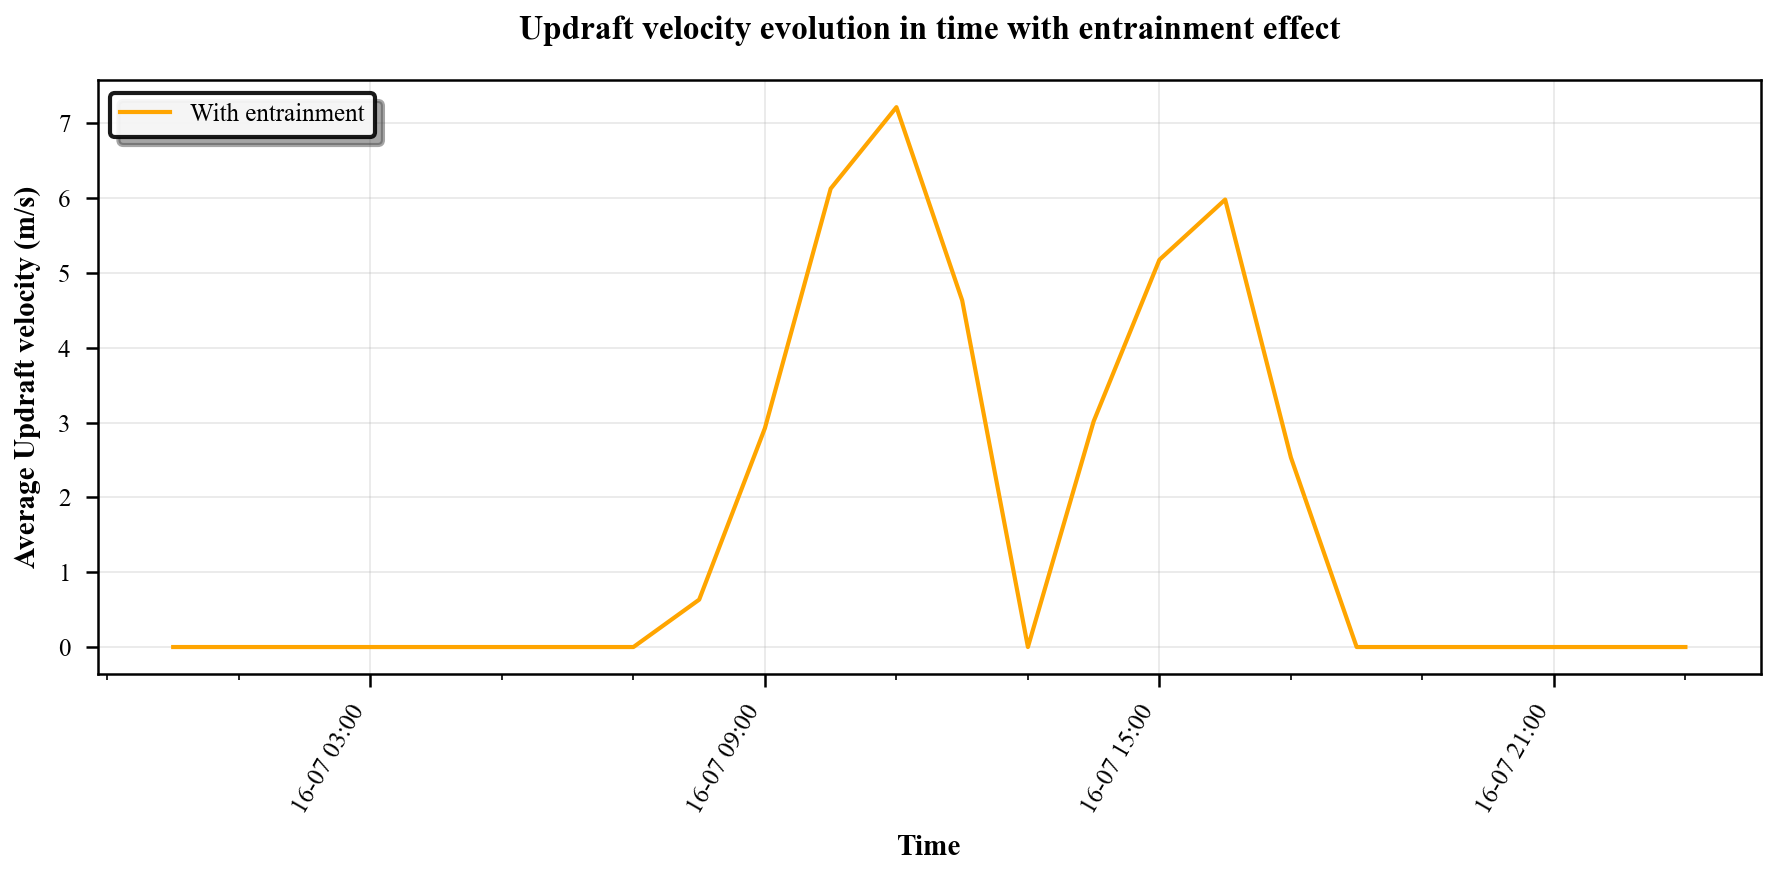

In [178]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
#ax.plot(time_dt, w_parcel_max_old/2,
#        color='blue', label='Without entrainment', linestyle='--', 
#        linewidth=2.0 * SCALE_FACTOR)

ax.plot(time_dt, w_parcel_max/2,
        color='orange', 
        label='With entrainment',
        linewidth=2.0 * SCALE_FACTOR)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Average Updraft velocity (m/s)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Updraft velocity evolution in time with entrainment effect',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Improved legend - scaled spacing
legend = ax.legend(loc='upper left',
                   frameon=True,
                   fancybox=True,
                   shadow=True,
                   framealpha=0.9,
                   edgecolor='black',
                   facecolor='white')

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [179]:
indices = np.where(R*3600>0.2)[0]
np.mean(w_parcel_max[indices]/2)

4.769905296517867

In [180]:
q_v_parcel_new - q_v_parcel

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.90200920e-05,  1.16663634e-04,  1.86163922e-04,
         1.90892723e-04,  1.81139779e-04,  1.60323559e-04,
         1.18829801e-04,  3.17564610e-05, -6.70059501e-05,
        -1.23108497e-04, -2.26587448e-04, -4.50623678e-04,
        -5.45241050e-04, -4.44729951e-04, -2.97493086e-04,
        -2.10652943e-04, -1.35482305e-04, -5.74243624e-05,
        -5.28953074e-05,  1.42922066e-05,  2.58363886e-05,
         2.72603284e-05],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -2.63861399e-04,  5.27721394e-05,  7.18319925e-05,
        -7.11265706e-06, -1.73750517e-04, -3.88961230e-04,
        -5.91401032e-04, -7.29247048e-04, -8.05665346e-04,
        -8.40741943e-04, -9.37360116e-04, -1.04611674e-03,
        -8.54750032e-04, -5.60159372e-04, -4.26741540e-04,
        -3.28691399e-04, -1.91809016e-04, -7.50760977e-05,
        -1.34373306e-05,  2.26767807e-05,  2.84514838e-05,
         2.53183717e-05],
    

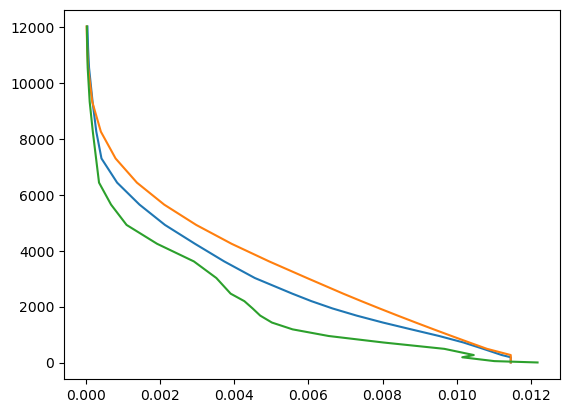

In [181]:
index = 2
#plt.plot(w_sat(T_d[index],p_new[index,0]) - q_v_parcel[index],Z_new[index],label='T_v_moist')
plt.plot(q_v_parcel_new[index],Z_new[index],label='q_l'   )
plt.plot(q_v_parcel[index],Z_new[index],label='q_v_parcel')
plt.plot(q_v_new[index],Z_new[index],label='q_v')
plt.show()

#### LWC and LWP(state)

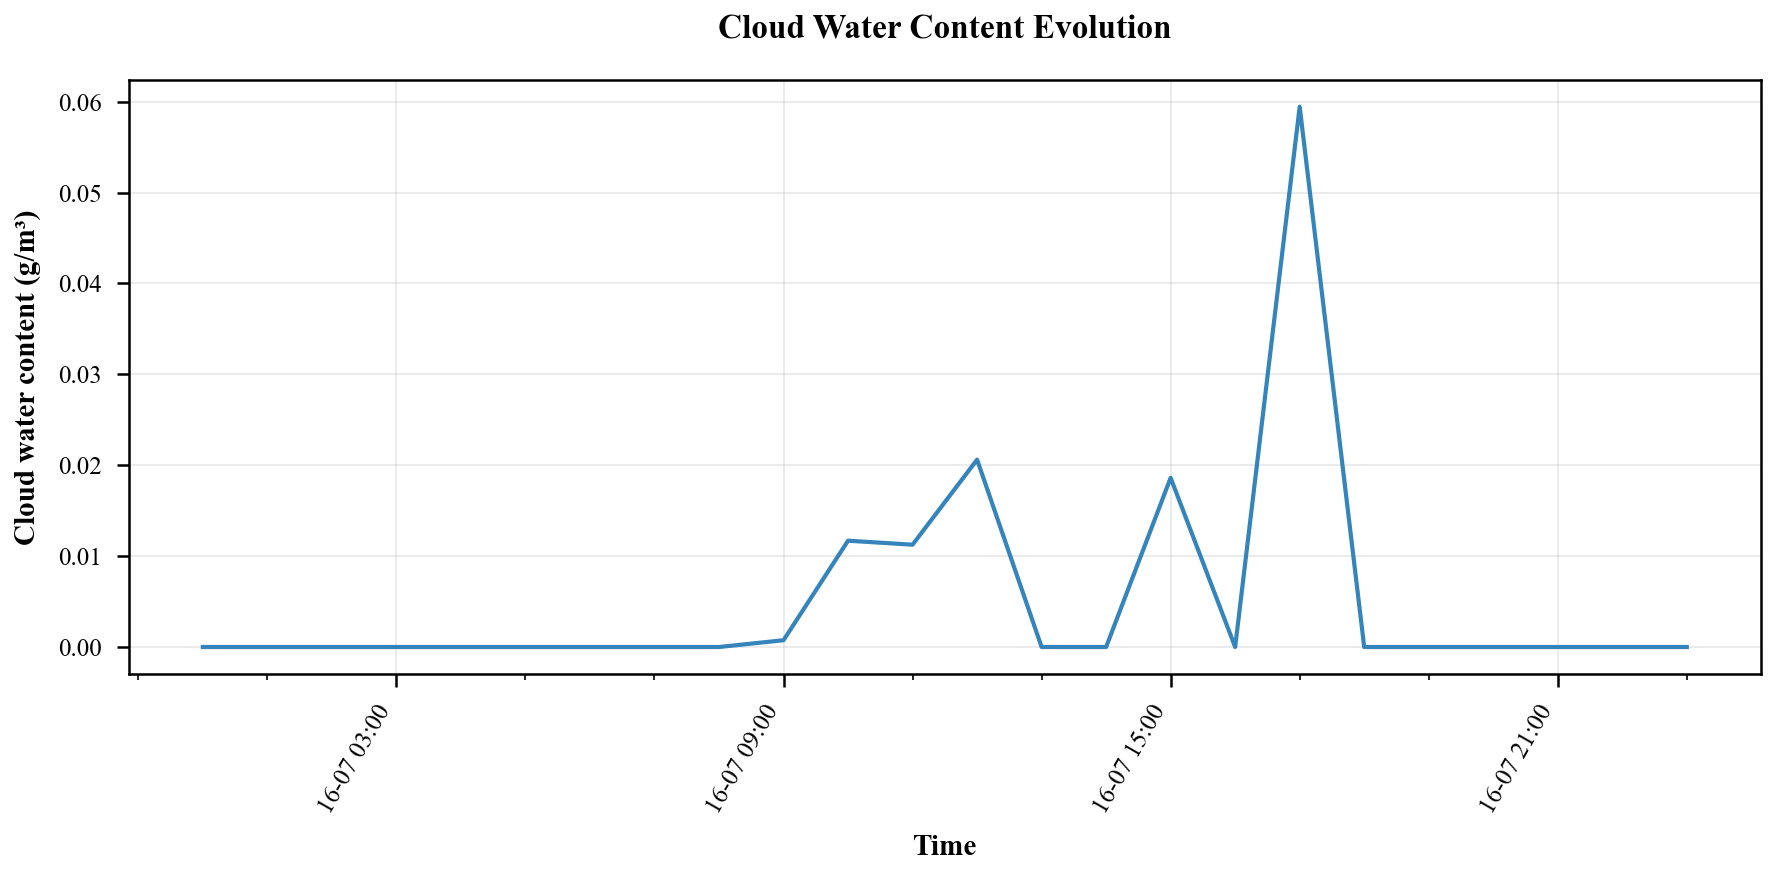

In [182]:
import pandas as pd

# SCALE FACTOR - Change this to scale the entire plot
SCALE_FACTOR = 0.5  # 1.0 = original size, 0.5 = half size, 0.25 = quarter size, etc.

# Scientific publication-quality styling - scaled by SCALE_FACTOR
plt.style.use('default')  # Start with clean slate
plt.rcParams.update({
    # Font settings - scaled by SCALE_FACTOR
    'font.size': 12 * SCALE_FACTOR,
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    
    # Axes and lines - scaled by SCALE_FACTOR
    'axes.linewidth': 1.2 * SCALE_FACTOR,
    'axes.labelsize': 14 * SCALE_FACTOR,
    'axes.titlesize': 16 * SCALE_FACTOR,
    
    # Ticks - scaled by SCALE_FACTOR
    'xtick.labelsize': 12 * SCALE_FACTOR,
    'ytick.labelsize': 12 * SCALE_FACTOR,
    
    # Legend - scaled by SCALE_FACTOR
    'legend.fontsize': 12 * SCALE_FACTOR,
    
    # Figure quality
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.1 * SCALE_FACTOR
})

import matplotlib.dates as mdates

# Convert time to datetime
time_dt = pd.to_datetime(time.values)

# Create figure - scaled by SCALE_FACTOR
fig, ax = plt.subplots(figsize=(12 * SCALE_FACTOR, 6 * SCALE_FACTOR))

# Plot with scaled line widths
ax.plot(time_dt, X / Z_c_new,
        color='#1f77b4',  # Default blue
        linewidth=2.0 * SCALE_FACTOR,
        alpha=0.9)

# Scale-aware date formatting
import matplotlib.dates as mdates

# Adaptive tick spacing based on scale factor and data range
data_duration = (time_dt.max() - time_dt.min()).total_seconds() / 3600  # Duration in hours

if SCALE_FACTOR >= 1.0:
    if data_duration <= 24:  # Less than 24 hours of data
        tick_interval = 2  # Every 2 hours
        minor_interval = 1  # Minor ticks every hour
    elif data_duration <= 72:  # Less than 3 days
        tick_interval = 6  # Every 6 hours
        minor_interval = 2  # Minor ticks every 2 hours
    else:  # More than 3 days
        tick_interval = 12  # Every 12 hours
        minor_interval = 4  # Minor ticks every 4 hours
    date_format = '%d-%m %H:%M'
    rotation = 45
elif SCALE_FACTOR >= 0.5:
    if data_duration <= 48:
        tick_interval = 6  # Every 6 hours
        minor_interval = 2
    else:
        tick_interval = 12  # Every 12 hours
        minor_interval = 4
    date_format = '%d-%m %H:%M'
    rotation = 60
else:
    tick_interval = 24  # Daily for small size
    minor_interval = 6   # Minor ticks every 6 hours
    date_format = '%d-%m'  # Just date for very small plots
    rotation = 45

# Format x-axis
ax.xaxis.set_major_formatter(mdates.DateFormatter(date_format))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=tick_interval))
ax.xaxis.set_minor_locator(mdates.HourLocator(interval=minor_interval))

# Rotate labels with scaled font size and better spacing
plt.setp(ax.xaxis.get_majorticklabels(), 
         rotation=rotation, 
         ha='right', 
         fontsize=12*SCALE_FACTOR)

# Scientific axis labels with units
ax.set_ylabel('Cloud water content (g/m³)', fontweight='bold')
ax.set_xlabel('Time', fontweight='bold')
ax.set_title('Cloud Water Content Evolution',
             fontweight='bold', pad=20 * SCALE_FACTOR)

# Scientific grid - scaled by SCALE_FACTOR
ax.grid(True, alpha=0.3, linewidth=0.8 * SCALE_FACTOR)
ax.set_axisbelow(True)

# Tick parameters - scaled by SCALE_FACTOR
ax.tick_params(which='major', 
               length=6 * SCALE_FACTOR, 
               width=1.2 * SCALE_FACTOR)
ax.tick_params(which='minor', 
               length=3 * SCALE_FACTOR, 
               width=0.8 * SCALE_FACTOR)

# Optional: Uncomment to set y-axis limits
#ax.set_ylim(0, 10)

# Tight layout for proper spacing
plt.tight_layout()

# Show the plot
plt.show()

# Reset all rcParams to matplotlib defaults
plt.rcParams.update(plt.rcParamsDefault)

In [183]:
a = len(time_dt) - len(hourly_avg.time)

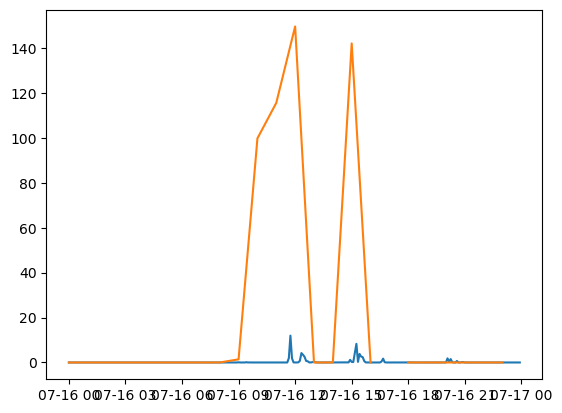

In [184]:
plt.plot(hourly_avg.time, hourly_avg)
plt.plot(time_dt,P*3600)
plt.show()

In [185]:
hourly_avg = hourly_avg.resample(time='1H').mean()
hourly_avg_model = P[0:-1].reshape(-1, 12).mean(axis=1)

c:\Users\chari\miniconda3\envs\mude\Lib\site-packages\xarray\groupers.py:490: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  self.index_grouper = pd.Grouper(


ValueError: cannot reshape array of size 23 into shape (12)

In [ ]:
hourly_avg_model

array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.46016605e-05,
       1.45984701e-04, 2.65110936e-04, 4.57109404e-04, 1.40478864e-03,
       3.62478870e-03, 5.93554659e-03, 9.14962767e-03, 1.32596801e-02,
       1.73040022e-02, 2.08786922e-02, 2.48868086e-02, 2.75886552e-02,
       2.94720745e-02, 3.09591997e-02,            nan,            nan,
      

In [ ]:
plt.plot(hourly_avg.time, hourly_avg.values)
plt.plot(hourly_avg.time[:-1], hourly_avg_model*3600)
plt.show()

ValueError: x and y must have same first dimension, but have shapes (23,) and (115,)

In [ ]:
hourly_avg

<xarray.DataArray 'rainfall_rate_32bit' (time: 24)> Size: 96B
array([0.0000000e+00, 0.0000000e+00, 3.8333333e-04, 3.2166669e-03,
       5.3666676e-03, 1.2833334e-03, 0.0000000e+00, 0.0000000e+00,
       0.0000000e+00, 1.9900000e-02, 0.0000000e+00, 1.3144333e+00,
       1.0263833e+00, 3.3233333e-02, 1.0043333e-01, 1.8810664e+00,
       1.8901668e-01, 5.1833335e-03, 1.7516665e-02, 4.9833334e-03,
       4.0328336e-01, 4.0000002e-04, 0.0000000e+00, 0.0000000e+00],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[s] 192B 2024-07-16 ... 2024-07-16T23:00:00
Attributes:
    long_name:  average rainfall rate over the last minute
    units:      mm/h
    comment:    Field 01 in technical documentation

In [ ]:
from scipy import stats
stats.pearsonr(P*3600, hourly_avg)

ValueError: x and y must have the same length.